# Görüntü İşleme — Ders Notu
> **Proje:** thermal-uav-lockon-tracker için temel bilgiler  
> **Amaç:** Görüntü işlemenin temellerini sıfırdan anlamak

---

## İçindekiler
1. Görüntü nedir? (Piksel, kanal, matris)
2. OpenCV temelleri
3. Renk uzayları (BGR, RGB, Grayscale, HSV)
4. Termal görüntü nedir?
5. Temel görüntü operasyonları
6. Filtreleme (blur, keskinleştirme)
7. Kenar tespiti (Edge detection)
8. Morfolojik operasyonlar
9. Eşikleme (Thresholding)
10. Kontur ve bounding box
11. Video okuma ve frame işleme
12. Projemize bağlantı: Termal drone tespiti için ne kullanacağız?

---
## 1. Görüntü Nedir?

Bir görüntü aslında sadece bir **sayı matrisi**dir.

- Her hücreye **piksel** denir.
- Her piksel 0-255 arasında bir değer tutar. (0 = siyah, 255 = beyaz)
- Renkli bir görüntüde 3 katman (kanal) vardır: **Mavi, Yeşil, Kırmızı**

```
Gri görüntü → shape: (yükseklik, genişlik)          örn: (480, 640)
Renkli görüntü → shape: (yükseklik, genişlik, kanal) örn: (480, 640, 3)
```

**Önemli:** OpenCV görüntüleri BGR sırasıyla okur, RGB değil! Bu sık karıştırılan bir detaydır.

Görüntü shape: (8, 8)
Veri tipi: uint8
Min piksel: 0
Max piksel: 255

Matrisin kendisi:
[[  0  30  60  90 120 150 180 255]
 [ 30  60  90 120 150 180 210 240]
 [ 60  90 120 150 180 210 240 255]
 [ 90 120 150 180 210 240 255 200]
 [120 150 180 210 240 255 200 150]
 [150 180 210 240 255 200 150 100]
 [180 210 240 255 200 150 100  50]
 [255 240 200 150 100  50  20   0]]


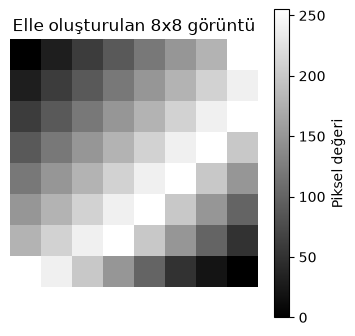

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sıfırdan elle bir görüntü oluşturalım — 8x8 gri görüntü
goruntu = np.array([
    [  0,  30,  60,  90, 120, 150, 180, 255],
    [ 30,  60,  90, 120, 150, 180, 210, 240],
    [ 60,  90, 120, 150, 180, 210, 240, 255],
    [ 90, 120, 150, 180, 210, 240, 255, 200],
    [120, 150, 180, 210, 240, 255, 200, 150],
    [150, 180, 210, 240, 255, 200, 150, 100],
    [180, 210, 240, 255, 200, 150, 100,  50],
    [255, 240, 200, 150, 100,  50,  20,   0],
], dtype=np.uint8)

print("Görüntü shape:", goruntu.shape)   # (8, 8) — 8x8 piksel, 1 kanal
print("Veri tipi:", goruntu.dtype)        # uint8 → 0-255 arası tam sayı
print("Min piksel:", goruntu.min())
print("Max piksel:", goruntu.max())
print()
print("Matrisin kendisi:")
print(goruntu)

plt.figure(figsize=(4, 4))
plt.imshow(goruntu, cmap='gray', vmin=0, vmax=255)
plt.title("Elle oluşturulan 8x8 görüntü")
plt.colorbar(label='Piksel değeri')
plt.axis('off')
plt.show()

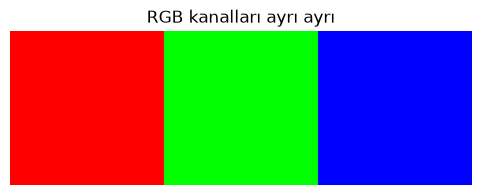

Renkli görüntü shape: (100, 300, 3)


In [5]:
# Renkli görüntü nasıl görünür?
# 3 kanallı: (yükseklik, genişlik, 3) → 3 = [Kırmızı, Yeşil, Mavi]

renkli = np.zeros((100, 300, 3), dtype=np.uint8)

# Sol üçte biri kırmızı
renkli[:, :100, 0] = 255   # R kanalı
# Orta üçte biri yeşil
renkli[:, 100:200, 1] = 255  # G kanalı
# Sağ üçte biri mavi
renkli[:, 200:, 2] = 255   # B kanalı

plt.figure(figsize=(8, 2))
plt.imshow(renkli)
plt.title("RGB kanalları ayrı ayrı")
plt.axis('off')
plt.show()

print("Renkli görüntü shape:", renkli.shape)  # (100, 300, 3)

---
## 2. OpenCV Temelleri

OpenCV (Open Computer Vision) görüntü işlemin en yaygın kütüphanesidir.  
Projemizde video okumak, kutu çizmek, frame kaydetmek için kullanacağız.

**Kritik fark:** OpenCV görüntüleri **BGR** sırasıyla okur.  
Matplotlib ise **RGB** bekler. Bu yüzden her gösterimde dönüşüm yapmak gerekir.

BURADAKİ MANTIK ASLINDA BGR OLAN SIRAYI RGB OLARAK OKUMAYALIM DİYE 

In [6]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
Note: you may need to restart the kernel to use updated packages.


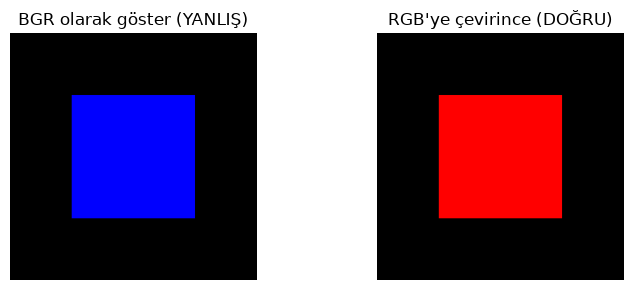

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Görüntü okuma ---
# Eğer bir görüntü dosyan varsa:
# img = cv2.imread('resim.jpg')  # BGR olarak okur!

# Şimdilik yapay bir görüntü oluşturalım
# 200x200 piksel, 3 kanallı (BGR)
img_bgr = np.zeros((200, 200, 3), dtype=np.uint8)
img_bgr[50:150, 50:150] = [0, 0, 255]  # BGR: yeşil kare

# OpenCV'de göstermek:
# cv2.imshow('pencere', img_bgr)  # Bu satır terminal/script'te çalışır

# Matplotlib'de göstermek için BGR→RGB çevir:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(img_bgr)  # Yanlış renkler (B ve R yer değişti)
axes[0].set_title("BGR olarak göster (YANLIŞ)")
axes[0].axis('off')

axes[1].imshow(img_rgb)  # Doğru renkler
axes[1].set_title("RGB'ye çevirince (DOĞRU)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Orijinal boyut: (480, 640, 3)
Küçültülmüş boyut: (240, 320, 3)
Kırpılmış boyut: (200, 300, 3)


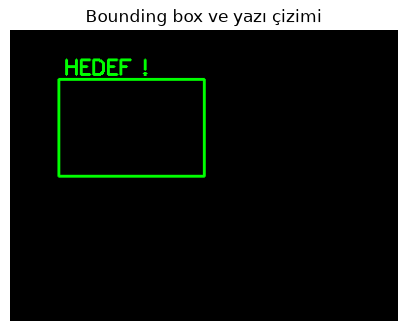

In [13]:
# --- Temel OpenCV işlemleri ---

# Boyut değiştirme (resize)
img = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
print("Orijinal boyut:", img.shape)  # (480, 640, 3)

kucuk = cv2.resize(img, (320, 240))  # (genişlik, yükseklik) — dikkat sıraya!
print("Küçültülmüş boyut:", kucuk.shape)  # (240, 320, 3)

# Kırpma (crop) — numpy slice ile yapılır
kirpilmis = img[100:300, 200:500]  # [y1:y2, x1:x2]
print("Kırpılmış boyut:", kirpilmis.shape)  # (200, 300, 3)

# Dikdörtgen çizme (bounding box için kullanacağız!)
goruntu = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.rectangle(
    goruntu,
    (50, 50),      # sol üst köşe (x1, y1)
    (200, 150),    # sağ alt köşe (x2, y2)
    (0, 255, 0),   # renk BGR: yeşil
    thickness=2    # çizgi kalınlığı
)

# Yazı yazdırma
cv2.putText(
    goruntu,
    'HEDEF !',         # metin
    (55, 45),        # konum (x, y)
    cv2.FONT_HERSHEY_SIMPLEX,  # font
    0.7,             # boyut
    (0, 255, 0),     # renk BGR
    2                # kalınlık
)   
# !!!!!!!! COMMAND SHİFT 7 İLE YORUMA ALMA İŞLEMİ YAPILDI

plt.figure(figsize=(5, 4))
plt.imshow(cv2.cvtColor(goruntu, cv2.COLOR_BGR2RGB))
plt.title("Bounding box ve yazı çizimi")
plt.axis('off')
plt.show()

---
## 3. Renk Uzayları

Aynı görüntüyü farklı koordinat sistemlerinde ifade edebiliriz:

| Renk uzayı | Kanallar | Ne için kullanılır? |
|---|---|---|
| **BGR/RGB** | Mavi, Yeşil, Kırmızı | Standart renkli görüntü |
| **Grayscale** | Tek kanal (0-255) | Basit işlemler, hız |
| **HSV** | Hue (ton), Saturation (doygunluk), Value (parlaklık) | Renk bazlı filtreleme |
| **Termal / IR** | Sıcaklık değeri → gri ton | Projemiz bu! |

**Termal görüntü:** Kamera sıcaklığı ölçer, sıcak nesneler parlak (beyaz/sarı), soğuk nesneler karanlık (siyah) görünür.

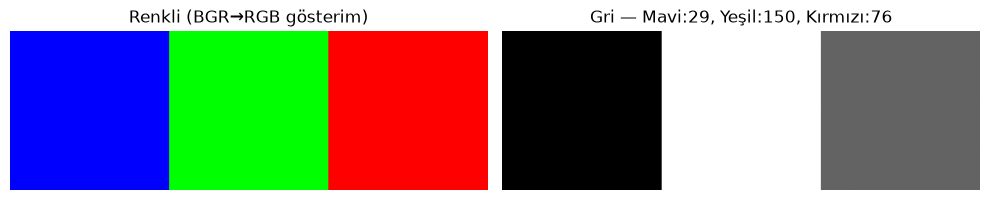

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Renkli → Gri dönüşümü
# Formül: Gray = 0.299*R + 0.587*G + 0.114*B
# (İnsan gözü yeşile daha duyarlı, bu yüzden ağırlıklar eşit değil)

renkli = np.zeros((200, 600, 3), dtype=np.uint8)
renkli[:, :200] = [255, 0, 0]    # Mavi (BGR)
renkli[:, 200:400] = [0, 255, 0] # Yeşil
renkli[:, 400:] = [0, 0, 255]    # Kırmızı

gri = cv2.cvtColor(renkli, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(cv2.cvtColor(renkli, cv2.COLOR_BGR2RGB))
axes[0].set_title("Renkli (BGR→RGB gösterim)")
axes[0].axis('off')

axes[1].imshow(gri, cmap='gray')
axes[1].set_title(f"Gri — Mavi:{gri[100,100]}, Yeşil:{gri[100,300]}, Kırmızı:{gri[100,500]}")
axes[1].axis('off') # AKSİSLERİ KAPATIYOR 

plt.tight_layout()
plt.show()

# Dikkat: Yeşil en parlak çıkıyor (0.587 katsayısı en büyük)
# Mavi en karanlık (0.114 katsayısı en küçük)

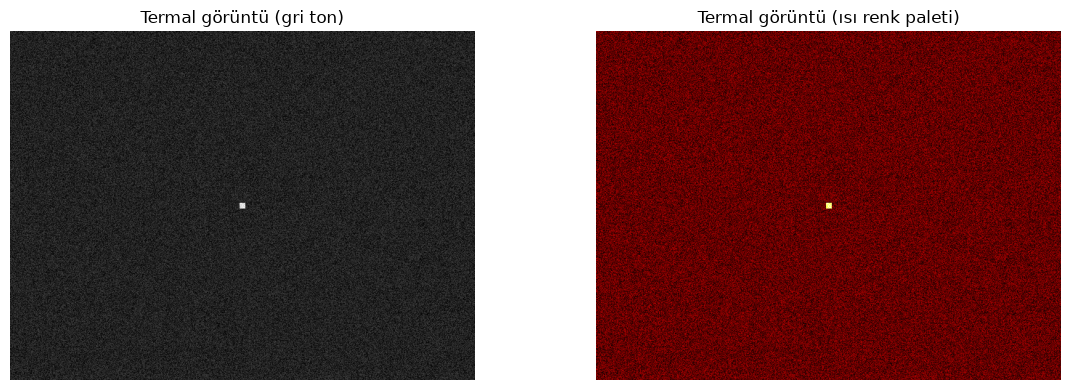

Drone konumu: (320, 240)
Drone piksel değeri: ~216
Arka plan piksel değeri: ~85

Neden zor? Drone sadece 64 piksel = görüntünün %0.021'i


In [20]:
# Termal görüntüyü simüle edelim
# Gerçekte: kamera sıcaklık verir → biz onu piksel değerine çeviririz
# Burada: sıcak bölgeler (drone) parlak, soğuk arka plan karanlık

np.random.seed(42)

# Soğuk arka plan (gece gökyüzü ~50-80 piksel)
termal = np.random.randint(40, 80, (480, 640), dtype=np.uint8) # 480 satır = y ekseni 640 sütun = x ekseni

# Sıcak hedef — drone'un motor ısısı (~200-240 piksel)
# Küçük: sadece 8x8 piksel (gerçekte böyle küçük!)
cx, cy = 320, 240  # merkez
termal[cy-4:cy+4, cx-4:cx+4] = np.random.randint(200, 240, (8, 8), dtype=np.uint8)

# Biraz gürültü ekle (gerçek termal kameraların gürültüsü)
gurultu = np.random.randint(-10, 10, termal.shape)
termal = np.clip(termal.astype(int) + gurultu, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gri tonlama
axes[0].imshow(termal, cmap='gray')
axes[0].set_title("Termal görüntü (gri ton)")
axes[0].axis('off')

# Isı haritası colormap — daha görsel
axes[1].imshow(termal, cmap='hot')
axes[1].set_title("Termal görüntü (ısı renk paleti)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Drone konumu: ({cx}, {cy})")
print(f"Drone piksel değeri: ~{termal[cy, cx]}")
print(f"Arka plan piksel değeri: ~{termal[10, 10]}")
print(f"\nNeden zor? Drone sadece {8*8} piksel = görüntünün %{8*8/(480*640)*100:.3f}'i")

---
## 4. Termal Görüntü Nedir?

Normal kamera (**visible light**): Güneş veya lambanın yansıttığı ışığı yakalar.  
Termal kamera (**IR / infrared**): Nesnelerin kendi yaydığı ısı radyasyonunu yakalar.

**Projemizde neden termal?**
- Gece de çalışır (ışık gerekmez)
- Drone'un motoru ısı yayar → karanlık gökyüzünde parlak nokta olarak görünür
- Kamuflaj işe yaramaz (gizlenemezsin, ısı yaymaya devam edersin)

**Zorluklar:**
- Hedef çok küçük: 5-15 piksel (640x480 görüntüde!)
- Arka plan gürültüsü var (sıcak kuşlar, güneş yansımaları)
- Kontrast düşük olabilir (hedef ile arka plan arasındaki fark az)

```
Gerçek termal görüntü piksel değerleri:
  Soğuk gece gökyüzü  : ~50-80
  Sıcak drone motoru  : ~200-240
  Sıcak bir kuş       : ~180-200  ← yanlış tespit tehlikesi!
```

---
## 5. Temel Görüntü Operasyonları

Görüntü işlemede en çok kullanılan matematiksel işlemler:

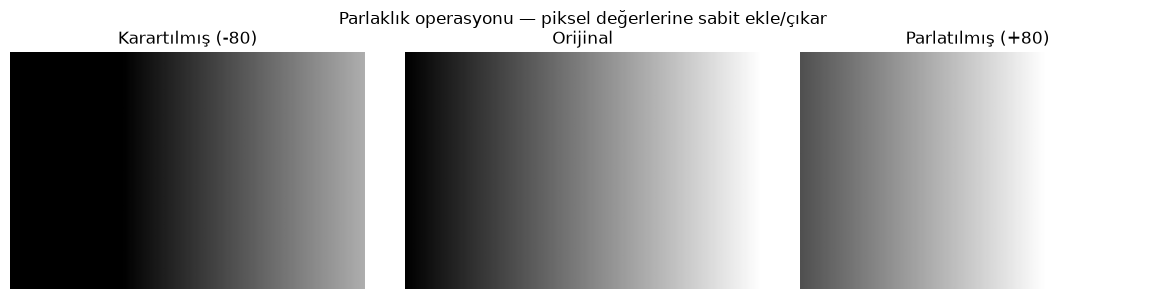

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Basit gradyan görüntü — soldan sağa kararan
img = np.tile(np.linspace(0, 255, 300, dtype=np.uint8), (200, 1))

# --- 1. Parlaklık artırma / azaltma ---
parlak = np.clip(img.astype(int) + 80, 0, 255).astype(np.uint8)  # +80
karanlik = np.clip(img.astype(int) - 80, 0, 255).astype(np.uint8)  # -80

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(karanlik, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Karartılmış (-80)")
axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Orijinal")
axes[2].imshow(parlak, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Parlatılmış (+80)")
for ax in axes:
    ax.axis('off')
plt.suptitle("Parlaklık operasyonu — piksel değerlerine sabit ekle/çıkar")
plt.tight_layout()
plt.show()

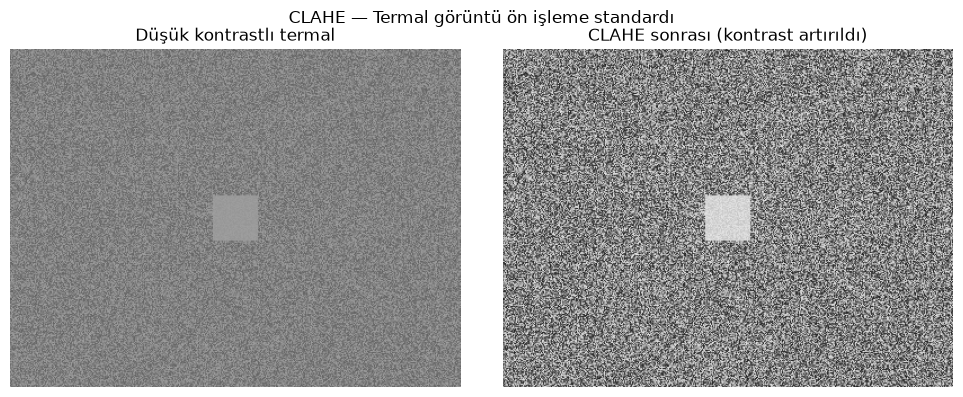

Orijinal değer aralığı: 100 - 159
CLAHE sonrası aralık: 36 - 230


In [22]:
# --- 2. Histogram Eşitleme (Histogram Equalization) ---
# Kontrast düşük görüntüleri iyileştirmenin klasik yöntemi
# Termal görüntülerde çok kullanılır!

# Düşük kontrastlı görüntü simüle et
dusuk_kontrast = np.random.randint(100, 160, (300, 400), dtype=np.uint8)
# Ortaya küçük bir "nesne" koy
dusuk_kontrast[130:170, 180:220] = np.random.randint(150, 160, (40, 40), dtype=np.uint8)

# CLAHE: Contrast Limited Adaptive Histogram Equalization
# Termal görüntü işlemede standart ön işleme adımı
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
iyilestirilmis = clahe.apply(dusuk_kontrast)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(dusuk_kontrast, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Düşük kontrastlı termal")
axes[0].axis('off')

axes[1].imshow(iyilestirilmis, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("CLAHE sonrası (kontrast artırıldı)")
axes[1].axis('off')

plt.suptitle("CLAHE — Termal görüntü ön işleme standardı")
plt.tight_layout()
plt.show()

print("Orijinal değer aralığı:", dusuk_kontrast.min(), "-", dusuk_kontrast.max())
print("CLAHE sonrası aralık:", iyilestirilmis.min(), "-", iyilestirilmis.max())

---
## 6. Filtreleme (Blur ve Keskinleştirme)

Filtre = görüntü üzerinde kayan küçük bir matris (**kernel**).  
Her piksel değeri, komşularıyla **ağırlıklı toplam** alınarak değiştirilir.

```
Gaussian Blur kerneli (3x3):
  1/16 * [[1, 2, 1],
           [2, 4, 2],
           [1, 2, 1]]

→ Merkez piksel 4 ağırlık alır, komşular azalan ağırlıkla eklenir
→ Sonuç: piksel değerleri yumuşar, görüntü bulanıklaşır (gürültü azalır)
```

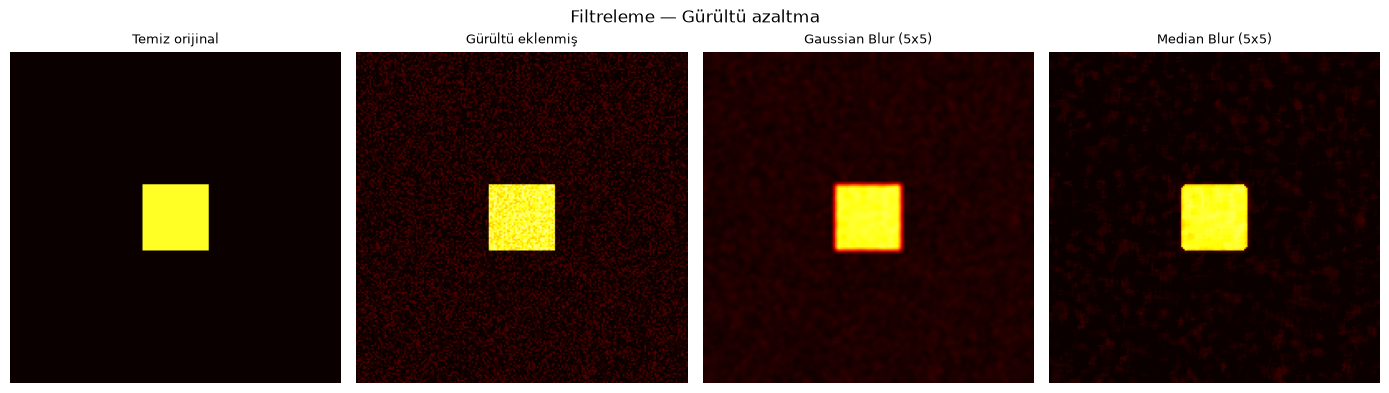

NOT: Termal görüntülerde genellikle hafif Gaussian blur ön işleme olarak kullanılır.
Çok fazla blur → küçük hedef kaybolur! Dikkatli kullan.


In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Gürültülü termal görüntü
np.random.seed(42)
temiz = np.zeros((200, 200), dtype=np.uint8)
temiz[80:120, 80:120] = 200  # sıcak nesne
gurultulu = np.clip(temiz.astype(int) + np.random.randint(-30, 30, temiz.shape), 0, 255).astype(np.uint8)

# Farklı blur yöntemleri
gaussian = cv2.GaussianBlur(gurultulu, (5, 5), sigmaX=1.5)
median = cv2.medianBlur(gurultulu, 5)  # Tuz-biber gürültüsüne karşı iyi

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
imgs = [temiz, gurultulu, gaussian, median]
titles = ["Temiz orijinal", "Gürültü eklenmiş", "Gaussian Blur (5x5)", "Median Blur (5x5)"]

for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im, cmap='hot', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Filtreleme — Gürültü azaltma")
plt.tight_layout()
plt.show()

print("NOT: Termal görüntülerde genellikle hafif Gaussian blur ön işleme olarak kullanılır.")
print("Çok fazla blur → küçük hedef kaybolur! Dikkatli kullan.")

---
## 7. Kenar Tespiti (Edge Detection)

Kenar = piksel değerinin hızla değiştiği yer.  
Matematiksel olarak bu, görüntünün **türevi** (gradyanı) yüksek olan noktalardır.

**Canny Edge Detector** — en yaygın yöntem, 4 adımı var:
1. Gaussian blur (gürültüyü azalt)
2. Sobel filtresi (x ve y yönünde gradyan hesapla)
3. Non-maximum suppression (sadece en güçlü kenarları tut)
4. Hysteresis thresholding (zayıf kenarları eleme)

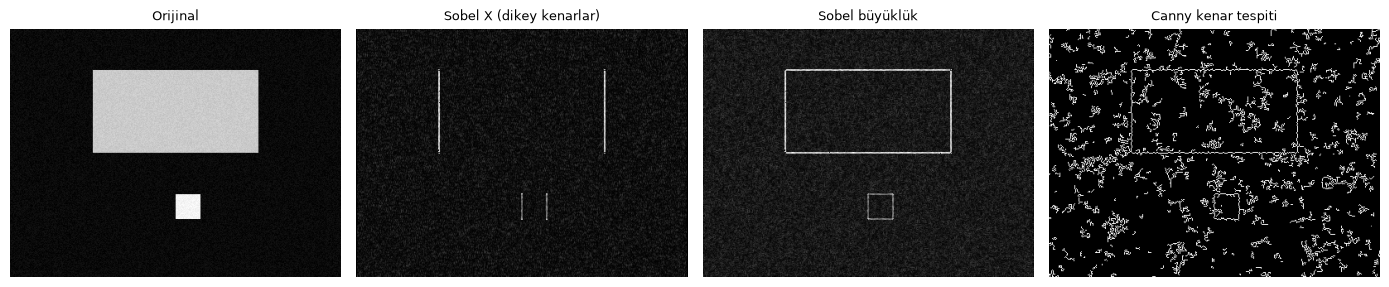

Projemizde kenar tespiti doğrudan kullanmıyoruz,
ama YOLO bu kavramları içinde otomatik öğreniyor.


In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Termal görüntü benzeri test
goruntu = np.zeros((300, 400), dtype=np.uint8)
goruntu[50:150, 100:300] = 180   # büyük nesne
goruntu[200:230, 200:230] = 220  # küçük nesne (drone gibi)
goruntu += np.random.randint(0, 20, goruntu.shape, dtype=np.uint8)

# Sobel: x ve y yönünde türev
sobel_x = cv2.Sobel(goruntu, cv2.CV_64F, 1, 0, ksize=3)  # yatay kenarlar
sobel_y = cv2.Sobel(goruntu, cv2.CV_64F, 0, 1, ksize=3)  # dikey kenarlar
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2).astype(np.uint8)  # toplam gradyan

# Canny: otomatik eşik, daha temiz
canny = cv2.Canny(goruntu, threshold1=30, threshold2=80)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
items = [
    (goruntu, 'gray', "Orijinal"),
    (np.abs(sobel_x).astype(np.uint8), 'gray', "Sobel X (dikey kenarlar)"),
    (sobel_mag, 'gray', "Sobel büyüklük"),
    (canny, 'gray', "Canny kenar tespiti")
]
for ax, (im, cmap, title) in zip(axes, items):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Projemizde kenar tespiti doğrudan kullanmıyoruz,")
print("ama YOLO bu kavramları içinde otomatik öğreniyor.")

---
## 8. Morfolojik Operasyonlar

Siyah-beyaz (binary) görüntülerde nesnelerin **şeklini** değiştirmek için kullanılır.

| Operasyon | Ne yapar? | Ne zaman kullanılır? |
|---|---|---|
| **Erosion (Aşındırma)** | Nesneleri küçültür | Gürültü noktalarını siler |
| **Dilation (Genişletme)** | Nesneleri büyütür | Kopuk bölgeleri birleştirir |
| **Opening** | Erosion → Dilation | Küçük gürültü noktalarını sil |
| **Closing** | Dilation → Erosion | Nesnedeki delikleri kapat |

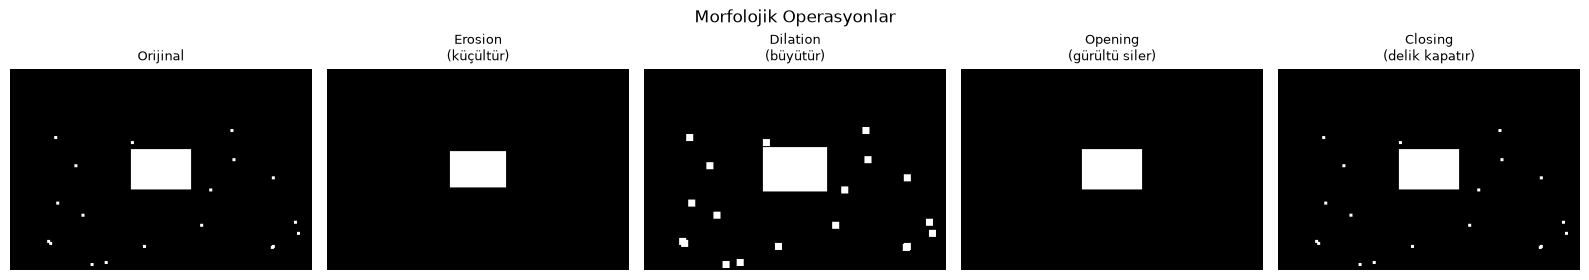

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Binary görüntü: hedef + gürültü noktaları
binary = np.zeros((200, 300), dtype=np.uint8)
binary[80:120, 120:180] = 255  # asıl hedef
# Gürültü noktaları (yanlış tespit benzeri)
for _ in range(20):
    x, y = np.random.randint(0, 300), np.random.randint(0, 200)
    binary[y:y+3, x:x+3] = 255

kernel = np.ones((5, 5), dtype=np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)   # gürültü sil
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)  # delik kapat

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
items = [binary, erosion, dilation, opening, closing]
titles = ["Orijinal", "Erosion\n(küçültür)", "Dilation\n(büyütür)",
          "Opening\n(gürültü siler)", "Closing\n(delik kapatır)"]
for ax, im, title in zip(axes, items, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Morfolojik Operasyonlar")
plt.tight_layout()
plt.show()

---
## 9. Eşikleme (Thresholding)

Gri görüntüyü siyah-beyaz (binary) görüntüye çevirme.  
Her piksel: eşik değerinin **üstündeyse beyaz (255)**, altındaysa siyah (0).

**Termal görüntüde kullanım:** Sıcak pikselleri (hedefi) ayır, soğuk arka planı sil.

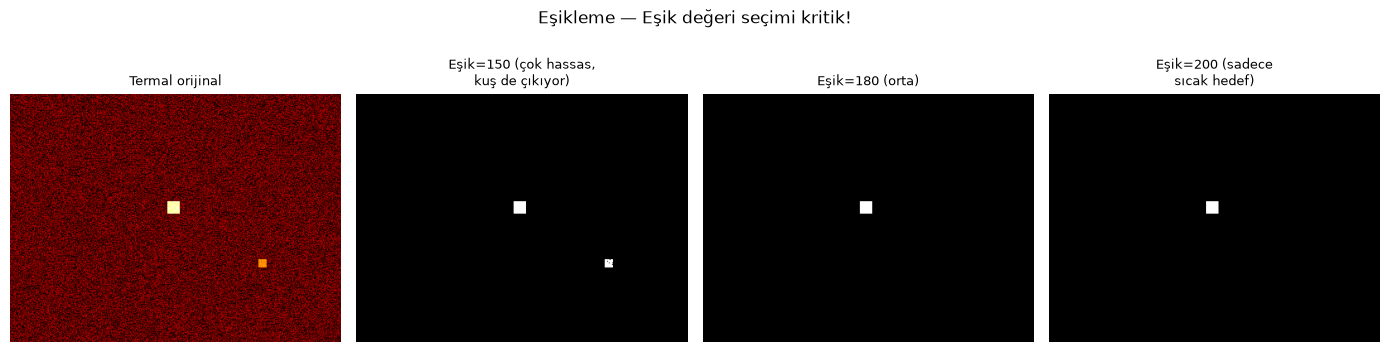

Derse not: Eşik çok düşük → yanlış tespitler artar (false positive)
           Eşik çok yüksek → gerçek hedef kaçar (false negative)
           Bu dengeye precision-recall tradeoff denir!


In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Termal görüntü simülasyonu
np.random.seed(7)
termal = np.random.randint(50, 100, (300, 400), dtype=np.uint8)  # arka plan
termal[130:145, 190:205] = np.random.randint(210, 240, (15, 15), dtype=np.uint8)  # drone
termal[200:210, 300:310] = np.random.randint(150, 170, (10, 10), dtype=np.uint8)  # kuş (yanlış hedef)

# Farklı eşikler
_, esik_150 = cv2.threshold(termal, 150, 255, cv2.THRESH_BINARY)
_, esik_180 = cv2.threshold(termal, 180, 255, cv2.THRESH_BINARY)
_, esik_200 = cv2.threshold(termal, 200, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
items = [
    (termal, 'hot', "Termal orijinal"),
    (esik_150, 'gray', "Eşik=150 (çok hassas,\nkuş de çıkıyor)"),
    (esik_180, 'gray', "Eşik=180 (orta)"),
    (esik_200, 'gray', "Eşik=200 (sadece\nsıcak hedef)"),
]
for ax, (im, cmap, title) in zip(axes, items):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Eşikleme — Eşik değeri seçimi kritik!")
plt.tight_layout()
plt.show()

print("Derse not: Eşik çok düşük → yanlış tespitler artar (false positive)")
print("           Eşik çok yüksek → gerçek hedef kaçar (false negative)")
print("           Bu dengeye precision-recall tradeoff denir!")

---
## 10. Kontur ve Bounding Box

Tespit sonrası hedefin etrafına dikdörtgen (bounding box) çizmek için kullanılır.  
**Kontur** = bir nesnenin dış sınırını oluşturan piksel listesi.

**Bounding box (bbox):** konturun etrafına çizilen en küçük dikdörtgen.
- Format: `(x, y, w, h)` → sol üst köşe x,y; genişlik w; yükseklik h
- Alternatif: `(x1, y1, x2, y2)` → iki köşe koordinatı (YOLO çıktısı bu formatta)

Hedef 1: bbox=(300,200,18,15), alan=238px², merkez=(309,207)
Hedef 2: bbox=(150,100,50,40), alan=1911px², merkez=(175,120)


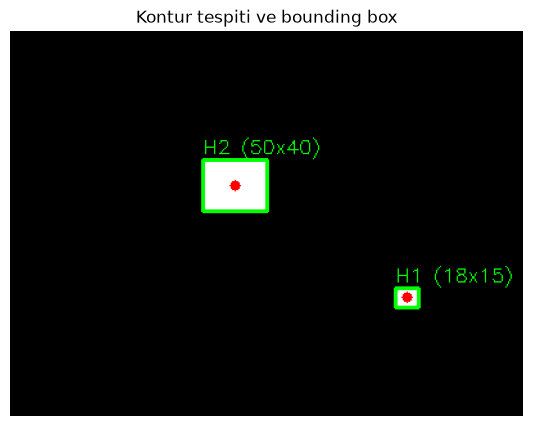

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Binary mask → kontur → bounding box
binary = np.zeros((300, 400), dtype=np.uint8)
binary[100:140, 150:200] = 255  # hedef 1
binary[200:215, 300:318] = 255  # hedef 2 (küçük — drone gibi)

# Konturları bul
konturlar, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Renkli görüntüye çiz
gosterim = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

for i, kontur in enumerate(konturlar):
    # Bounding box hesapla
    x, y, w, h = cv2.boundingRect(kontur)  # (x, y, genişlik, yükseklik)
    alan = cv2.contourArea(kontur)
    cx, cy = x + w // 2, y + h // 2  # merkez
    
    # Kutu çiz
    cv2.rectangle(gosterim, (x, y), (x+w, y+h), (0, 255, 0), 2)
    # Merkez nokta
    cv2.circle(gosterim, (cx, cy), 4, (0, 0, 255), -1)
    # Label
    cv2.putText(gosterim, f"H{i+1} ({w}x{h})", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    print(f"Hedef {i+1}: bbox=({x},{y},{w},{h}), alan={alan:.0f}px², merkez=({cx},{cy})")

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(gosterim, cv2.COLOR_BGR2RGB))
plt.title("Kontur tespiti ve bounding box")
plt.axis('off')
plt.show()

---
## 11. Video Okuma ve Frame İşleme

Anti-UAV veri seti video dosyaları içeriyor.  
OpenCV ile video okuma döngüsü **projemizin ana döngüsüdür.**

```
Her frame için:
  1. Frame oku
  2. Tespit yap (YOLO)
  3. Kalman predict
  4. Data association
  5. Kalman update
  6. Görselleştir
  7. Kaydet / göster
```

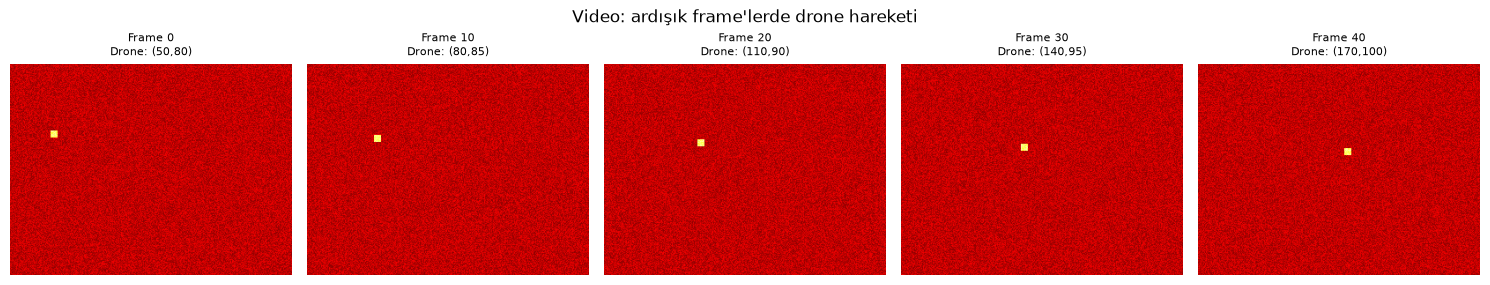

Kritik soru: Frame 20 ile Frame 21 arasındaki bağlantıyı nasıl kurarız?
Cevap: Kalman filtresi + data association → Hafta 2!


In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Gerçek video için:
# cap = cv2.VideoCapture('video.mp4')
# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break
#     # frame işle...
# cap.release()

# Şimdi sahte frame'lerle simüle edelim
# Drone 45 frame boyunca hareket ediyor

def sahte_frame_olustur(frame_no, genislik=320, yukseklik=240):
    """Hareketli drone içeren sahte termal frame oluştur"""
    frame = np.random.randint(50, 90, (yukseklik, genislik), dtype=np.uint8)
    
    # Drone sağa ve biraz aşağıya hareket ediyor
    dx = int(frame_no * 3)
    dy = int(frame_no * 0.5)
    cx = 50 + dx
    cy = 80 + dy
    
    if 0 < cx < genislik and 0 < cy < yukseklik:
        frame[cy-4:cy+4, cx-4:cx+4] = np.random.randint(200, 235, (8, 8), dtype=np.uint8)
    
    return frame, (cx, cy)

# 5 frame'i göster
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, frame_no in enumerate([0, 10, 20, 30, 40]):
    frame, (cx, cy) = sahte_frame_olustur(frame_no)
    axes[i].imshow(frame, cmap='hot', vmin=0, vmax=255)
    axes[i].set_title(f"Frame {frame_no}\nDrone: ({cx},{cy})", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Video: ardışık frame'lerde drone hareketi")
plt.tight_layout()
plt.show()

print("Kritik soru: Frame 20 ile Frame 21 arasındaki bağlantıyı nasıl kurarız?")
print("Cevap: Kalman filtresi + data association → Hafta 2!")

In [74]:
# Video yazma — demo videosu kaydetmek için
# Projede kullanacağımız kod şablonu:

# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # codec
# out = cv2.VideoWriter(
#     'demo_output.mp4',   # çıktı dosyası
#     fourcc,
#     30,                  # FPS
#     (640, 480)           # (genişlik, yükseklik)
# )
#
# while ...
#     # işlenmiş frame'i yaz
#     out.write(frame_bgr)  # dikkat: BGR formatında olmalı!
#
# out.release()

print("Video yazma şablonu hazır — Hafta 2'de kullanacağız.")

Video yazma şablonu hazır — Hafta 2'de kullanacağız.


---
## 12. IoU (Intersection over Union) — Bounding Box Kalitesi

İki bounding box ne kadar üst üste biniyor? Bu ölçüm:
- Tespit kalitesini ölçmek için (tahmin vs gerçek)
- Data association'da iz-tespit eşleşme maliyeti olarak

```
IoU = Kesişim Alanı / Birleşim Alanı

IoU = 1.0 → Mükemmel örtüşme
IoU = 0.0 → Hiç örtüşme yok
IoU > 0.5 → Genellikle "iyi tespit" kabul edilir
```

Yakın tahmin IoU: 0.730
Uzak tahmin IoU:  0.000


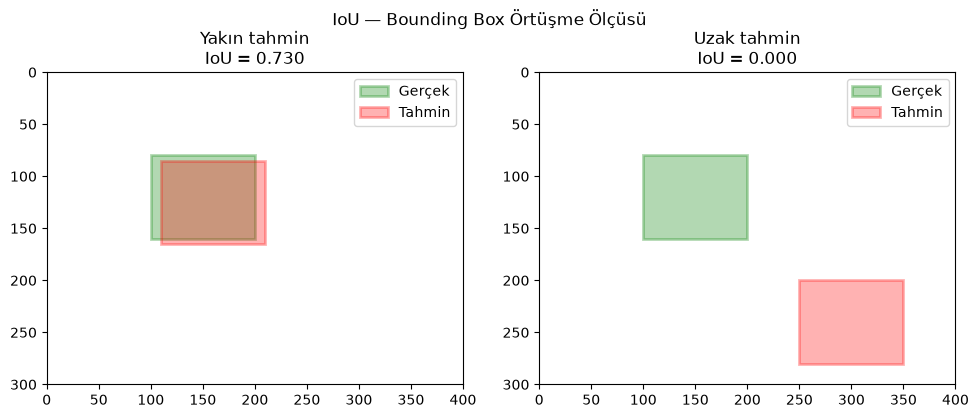

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def iou_hesapla(box1, box2):
    """
    İki bounding box arasındaki IoU'yu hesapla.
    box format: (x1, y1, x2, y2)
    """
    # Kesişim dikdörtgeninin koordinatları
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Kesişim alanı (negatif olamaz)
    kesisim_w = max(0, x2 - x1)
    kesisim_h = max(0, y2 - y1)
    kesisim_alani = kesisim_w * kesisim_h
    
    # Her kutunun alanı
    alan1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    alan2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    # Birleşim alanı
    birlesim_alani = alan1 + alan2 - kesisim_alani
    
    return kesisim_alani / birlesim_alani if birlesim_alani > 0 else 0.0

# Test
gercek_box  = (100, 80, 200, 160)  # ground truth
tahmin_box1 = (110, 85, 210, 165)  # yakın tahmin
tahmin_box2 = (250, 200, 350, 280) # uzak tahmin

iou1 = iou_hesapla(gercek_box, tahmin_box1)
iou2 = iou_hesapla(gercek_box, tahmin_box2)

print(f"Yakın tahmin IoU: {iou1:.3f}")
print(f"Uzak tahmin IoU:  {iou2:.3f}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, tahmin, iou, title in zip(
    axes,
    [tahmin_box1, tahmin_box2],
    [iou1, iou2],
    ["Yakın tahmin", "Uzak tahmin"]
):
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 300)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    g = gercek_box
    t = tahmin
    ax.add_patch(patches.Rectangle((g[0], g[1]), g[2]-g[0], g[3]-g[1],
                 linewidth=2, edgecolor='green', facecolor='green', alpha=0.3, label='Gerçek'))
    ax.add_patch(patches.Rectangle((t[0], t[1]), t[2]-t[0], t[3]-t[1],
                 linewidth=2, edgecolor='red', facecolor='red', alpha=0.3, label='Tahmin'))
    ax.set_title(f"{title}\nIoU = {iou:.3f}")
    ax.legend()

plt.suptitle("IoU — Bounding Box Örtüşme Ölçüsü")
plt.tight_layout()
plt.show()

---
## 13. Projemize Bağlantı — Tüm Parçalar

Şimdiye kadar öğrendiklerini projede nerede kullanacaksın:

| Kavram | Projede kullanım yeri |
|---|---|
| Piksel / matris | Her şeyin temeli |
| OpenCV imread/VideoCapture | Anti-UAV videolarını okuma |
| Gri dönüşüm | Termal zaten gri, ama gerekirse |
| CLAHE | Kontrast iyileştirme (ön işleme) |
| Gaussian blur | Gürültü azaltma (ön işleme) |
| Bounding box | YOLO çıktısı, Kalman durumu |
| IoU | Data association maliyet matrisi |
| VideoWriter | Demo video kayıt |
| cv2.rectangle / putText | Kilitli/tahmin kutularını çizme |

**YOLO** ise tüm bu düşük seviye işlemleri otomatik yapan bir model — siz sadece `detect(frame)` çağırıyorsunuz, geri kalanı YOLO hallediyor.

**Sonraki adım:** `src/detector.py` dosyasını yaz!

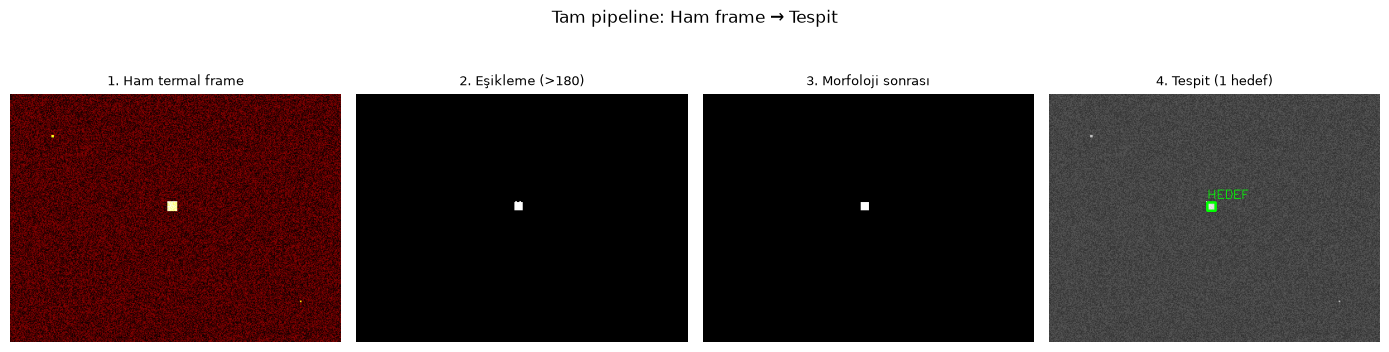

Tespit edilen hedef sayısı: 1
  Hedef 1: bbox=(191,131,201,141), boyut=10x10px


In [76]:
# Özet: bir frame'den tespit kutularına kadar tam akış

import cv2
import numpy as np
import matplotlib.pyplot as plt

def tam_pipeline_demo(frame_gri):
    """
    Ön işleme → Eşikleme → Kontur → Bounding box
    (YOLO olmadan basit tespit — ne yaptığını anlamak için)
    """
    # 1. Gürültü azalt
    blur = cv2.GaussianBlur(frame_gri, (5, 5), 1.0)
    
    # 2. Yüksek sıcaklık bölgelerini ayır
    _, binary = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY)
    
    # 3. Gürültü noktalarını sil
    kernel = np.ones((3, 3), dtype=np.uint8)
    temiz = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # 4. Kontur bul → bounding box
    konturlar, _ = cv2.findContours(temiz, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    kutular = []
    for k in konturlar:
        alan = cv2.contourArea(k)
        if alan > 5:  # çok küçük gürültüyü ele
            x, y, w, h = cv2.boundingRect(k)
            kutular.append((x, y, x+w, y+h))
    
    return blur, binary, temiz, kutular

# Test frame
np.random.seed(3)
frame = np.random.randint(50, 90, (300, 400), dtype=np.uint8)
frame[130:142, 190:202] = np.random.randint(210, 240, (12, 12), dtype=np.uint8)  # drone
frame[50:53, 50:53] = 195   # gürültü
frame[250:252, 350:352] = 185  # gürültü

blur, binary, temiz, kutular = tam_pipeline_demo(frame)

# Görselleştir
gosterim = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
for (x1, y1, x2, y2) in kutular:
    cv2.rectangle(gosterim, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(gosterim, 'HEDEF', (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
items = [
    (frame, 'hot', "1. Ham termal frame"),
    (binary, 'gray', "2. Eşikleme (>180)"),
    (temiz, 'gray', "3. Morfoloji sonrası"),
    (cv2.cvtColor(gosterim, cv2.COLOR_BGR2RGB), None, f"4. Tespit ({len(kutular)} hedef)")
]
for ax, (im, cmap, title) in zip(axes, items):
    if cmap:
        ax.imshow(im, cmap=cmap)
    else:
        ax.imshow(im)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Tam pipeline: Ham frame → Tespit")
plt.tight_layout()
plt.show()

print(f"Tespit edilen hedef sayısı: {len(kutular)}")
for i, (x1,y1,x2,y2) in enumerate(kutular):
    print(f"  Hedef {i+1}: bbox=({x1},{y1},{x2},{y2}), boyut={x2-x1}x{y2-y1}px")

---
## Özet — Ne Öğrendik?

```
Görüntü = sayı matrisi (piksel değerleri 0-255)
OpenCV  = görüntü işleme aracı (BGR okur!)
Gri     = tek kanallı, termal görüntü böyle gelir
CLAHE   = kontrast iyileştirme (termal ön işleme)
Blur    = gürültü azaltma
Eşik    = sıcak pikseli ayır
Kontur  = nesne sınırı
Bbox    = nesnenin etrafındaki kutu (x1,y1,x2,y2)
IoU     = iki kutunun örtüşme oranı
```

**Bir sonraki ders:**  
YOLO ile otomatik tespit → `detector.py` yazımı  
SAHI ile küçük hedef iyileştirme

---
*Ders notu sonu — Anti-UAV verisi gelince koda geçiyoruz!*